In [1]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
import optuna

from sklearn.metrics import auc
from IPython.display import clear_output

from copy import deepcopy
from sklearn.utils.validation import check_consistent_length
# from tqdm import tqdm
from tqdm.auto import tqdm
# from utils import relative_uplift_auc_score, principled_uplift_curve, max_principled_uplift_curve, principled_uplift_auc_score, plot_principled_uplift_curve, sep_qini_auc_score

import warnings
warnings.filterwarnings('ignore')

from sklearn.utils.extmath import stable_cumsum
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import auc
from scipy import stats
from itertools import combinations

from causallearn.search.ConstraintBased.PC import pc

from sklift.metrics import uplift_by_percentile

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [3]:
SEED = 42

In [4]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [5]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [6]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [7]:
# Заполнение пропусков
data = data.fillna(-100)

In [8]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [9]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [10]:
X_val.shape

(137397, 193)

In [11]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):
    X_selected = X[selected_features]
    
    pred_c = model_c.predict_proba(X_selected)[:, 1]
    pred_t = model_t.predict_proba(X_selected)[:, 1]
    
    uplift_pred = pred_t - pred_c
    
    pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})
    auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
    puc = principled_uplift_auc_score(y, uplift_pred, treatment)
  
    print('AUUC:', auuc.squeeze())
    print('PUC:', puc)
    
    return uplift_pred, auuc, puc

In [12]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50, metrics='puc'):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val, puc_val = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        if metrics == 'auuc':
            return auuc_val.item()
        
        elif metrics == 'puc':
            return puc_val


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train, puc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, puc_train, study

In [13]:
def check_is_binary(array):
    if not np.all(np.unique(array) == np.array([0, 1])):
        raise ValueError(
            f'Input array is not binary. Got values {np.unique(array)}.'
        )
        
def principled_uplift_curve(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    desc_score_indices = np.argsort(uplift, kind='mergesort')[::-1]
    y_true = y_true[desc_score_indices]
    treatment = treatment[desc_score_indices]

    n_y1_t1 = np.zeros_like(y_true)
    n_y0_t0 = np.zeros_like(y_true)
    n_y1_t0 = np.zeros_like(y_true)
    n_y0_t1 = np.zeros_like(y_true)

    n_y1_t1[np.where((y_true == 1) & (treatment == 1))] = 1
    n_y0_t0[np.where((y_true == 0) & (treatment == 0))] = 1
    n_y1_t0[np.where((y_true == 1) & (treatment == 0))] = 1
    n_y0_t1[np.where((y_true == 0) & (treatment == 1))] = 1
    
    cum_y1_t1 = stable_cumsum(n_y1_t1)
    cum_y0_t0 = stable_cumsum(n_y0_t0)
    cum_y1_t0 = stable_cumsum(n_y1_t0)
    cum_y0_t1 = stable_cumsum(n_y0_t1)

    curve_values = cum_y1_t1 + cum_y0_t0 - cum_y1_t0 - cum_y0_t1
    return curve_values

def max_principled_uplift_curve(y_true, treatment):

    check_consistent_length(y_true, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    treatment = np.array(treatment)

    perfect_uplift = np.zeros_like(y_true)
    perfect_uplift[treatment == y_true] = 1

    return principled_uplift_curve(y_true, perfect_uplift, treatment)

def principled_uplift_auc_score(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    x_actual = np.array(range(len(y_true)))
    y_actual = principled_uplift_curve(y_true, uplift, treatment)
    y_perfect = max_principled_uplift_curve(y_true, treatment)

    x_baseline = np.array([0, x_actual[-1]])
    y_baseline = np.array([0, y_perfect[-1]])

    auc_baseline = auc(x_baseline, y_baseline)
    auc_perfect = auc(x_actual, y_perfect) - auc_baseline
    auc_actual = auc(x_actual, y_actual) - auc_baseline

    if auc_perfect == 0:
        return 0.0
    return auc_actual / auc_perfect


In [14]:
def _compute_puc_for_feature(X_col, y, treatment, n_bins=5):
    
    X_col = np.array(X_col, dtype=float)
    
    col_range = X_col.max() - X_col.min()
    if col_range == 0:
        return 0.0
    X_norm = (X_col - X_col.min()) / col_range

    try:
        score = principled_uplift_auc_score(y, X_norm, treatment)
    except Exception:
        score = 0.0
    return score

In [15]:
def _compute_marginal_puc(X, y, treatment, selected_features, candidate):
    
    if len(selected_features) == 0:
        base_scores = np.zeros(len(y))
    else:
        base_scores = X[:, selected_features].mean(axis=1)
        base_range = base_scores.max() - base_scores.min()
        if base_range > 0:
            base_scores = (base_scores - base_scores.min()) / base_range

    cand_scores = X[:, candidate].copy()
    cand_range = cand_scores.max() - cand_scores.min()
    if cand_range > 0:
        cand_scores = (cand_scores - cand_scores.min()) / cand_range

    combined = (base_scores + cand_scores) / 2

    try:
        return principled_uplift_auc_score(y, combined, treatment)
    except Exception:
        return 0.0

### Метод 1 - puc_filter_selector — фильтрационный отбор признаков на основе PUC


Метод оценивает каждый признак независимо по тому, насколько хорошо его значения ранжируют объекты по индивидуальному каузальному эффекту (uplift). Признаки с высоким PUC-AUC отбираются.

In [16]:
def puc_filter_selector(
    X,
    y,
    treatment,
    threshold=0.0,
    top_k=None,
    feature_names=None
):

    X = np.array(X)
    y = np.array(y)
    treatment = np.array(treatment)
    n_features = X.shape[1]
    
    scores = []
    for i in range(n_features):
        score = _compute_puc_for_feature(X[:, i], y, treatment)
        scores.append(score)
    
    feature_scores = np.array(scores)
    
    if top_k is not None:
        selected_idx = np.argsort(feature_scores)[::-1][:top_k]
    else:
        selected_idx = np.where(feature_scores >= threshold)[0]
    
    summary_df = pd.DataFrame({
        'feature': feature_names,
        'puc_auc': feature_scores,
        'selected': [i in selected_idx for i in range(len(feature_names))]
    }).sort_values('puc_auc', ascending=False).reset_index(drop=True)
    
    return selected_idx, feature_scores, summary_df


In [17]:
selected_idx_filter, feature_scores_filter, summary_df_filter = puc_filter_selector(X_train, y_train, treatment_train, 
                                                                                    threshold=0.0, feature_names=X_train.columns.tolist())

In [18]:
selected_features_filter = summary_df_filter[summary_df_filter.selected == True]['feature']

In [19]:
model_t_v1, model_c_v1, uplift_pred_train_v1, auuc_train_v1, puc_train_v1, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_filter)

[I 2026-05-02 17:42:45,335] A new study created in memory with name: no-name-ff1a9864-89ef-47d5-8f5f-4b9c07f19353
[I 2026-05-02 17:46:11,979] Trial 13 finished with value: 0.016181682823274562 and parameters: {'depth_c': 7, 'learning_rate_c': 0.07810303127349565, 'iterations_c': 370, 'l2_leaf_reg_c': 3.8447526788808615, 'bagging_temperature_c': 3.385237938630661, 'random_strength_c': 9.316354691604122, 'min_data_in_leaf_c': 91, 'depth_t': 8, 'learning_rate_t': 0.17197499645793712, 'iterations_t': 459, 'l2_leaf_reg_t': 7.919366362384343, 'bagging_temperature_t': 8.072747934298937, 'random_strength_t': 9.386650229930023, 'min_data_in_leaf_t': 29}. Best is trial 13 with value: 0.016181682823274562.


AUUC: 0.6464168120301926
PUC: 0.016181682823274562


[I 2026-05-02 17:46:35,824] Trial 12 finished with value: 0.04979961901534077 and parameters: {'depth_c': 5, 'learning_rate_c': 0.012875935892705092, 'iterations_c': 869, 'l2_leaf_reg_c': 1.3942900594310537, 'bagging_temperature_c': 0.48497333678136023, 'random_strength_c': 7.0496573378491165, 'min_data_in_leaf_c': 81, 'depth_t': 4, 'learning_rate_t': 0.08998708973641761, 'iterations_t': 723, 'l2_leaf_reg_t': 7.068177257196753, 'bagging_temperature_t': 7.917787956663957, 'random_strength_t': 9.254430656163645, 'min_data_in_leaf_t': 33}. Best is trial 12 with value: 0.04979961901534077.


AUUC: 0.612801444738967
PUC: 0.04979961901534077


[I 2026-05-02 17:48:27,999] Trial 6 finished with value: 0.03320770382944488 and parameters: {'depth_c': 9, 'learning_rate_c': 0.11321761665292884, 'iterations_c': 481, 'l2_leaf_reg_c': 2.1824323961005385, 'bagging_temperature_c': 1.6003607307521117, 'random_strength_c': 6.999684991361993, 'min_data_in_leaf_c': 82, 'depth_t': 5, 'learning_rate_t': 0.01925759615856802, 'iterations_t': 821, 'l2_leaf_reg_t': 13.081784458688427, 'bagging_temperature_t': 0.987472029117823, 'random_strength_t': 1.218463287128423, 'min_data_in_leaf_t': 14}. Best is trial 12 with value: 0.04979961901534077.


...

AUUC: 0.5041089085522474
PUC: 0.042694665034661794


[I 2026-05-02 18:25:25,844] Trial 48 finished with value: 0.04286656699498927 and parameters: {'depth_c': 10, 'learning_rate_c': 0.015461292217044502, 'iterations_c': 770, 'l2_leaf_reg_c': 10.07413449353917, 'bagging_temperature_c': 5.726644436643744, 'random_strength_c': 3.3987450855357895, 'min_data_in_leaf_c': 74, 'depth_t': 4, 'learning_rate_t': 0.051131195222775074, 'iterations_t': 1079, 'l2_leaf_reg_t': 2.7775645690017163, 'bagging_temperature_t': 4.485915386506123, 'random_strength_t': 6.251054972438624, 'min_data_in_leaf_t': 73}. Best is trial 30 with value: 0.05568166966404957.


AUUC: 0.5772522688515703
PUC: 0.04286656699498927


[I 2026-05-02 18:25:27,358] Trial 49 finished with value: 0.04401049602744273 and parameters: {'depth_c': 10, 'learning_rate_c': 0.015750432295944434, 'iterations_c': 754, 'l2_leaf_reg_c': 10.996847367168956, 'bagging_temperature_c': 9.834004555233317, 'random_strength_c': 3.7225970808575592, 'min_data_in_leaf_c': 75, 'depth_t': 4, 'learning_rate_t': 0.051771279177656976, 'iterations_t': 1088, 'l2_leaf_reg_t': 5.552904110539145, 'bagging_temperature_t': 4.518792405757628, 'random_strength_t': 6.239701327914293, 'min_data_in_leaf_t': 74}. Best is trial 30 with value: 0.05568166966404957.


AUUC: 0.5077254733704337
PUC: 0.04401049602744273
AUUC: 1.8400536303529385
PUC: 0.11521444825553381


In [20]:
uplift_pred_test_v1, auuc_test_v1, puc_test_v1 = get_uplift(model_t_v1, model_c_v1, X_test, treatment_test, y_test, selected_features_filter)

AUUC: 0.6957284426867127
PUC: 0.058256534073828276


In [21]:
len(selected_features_filter)

189

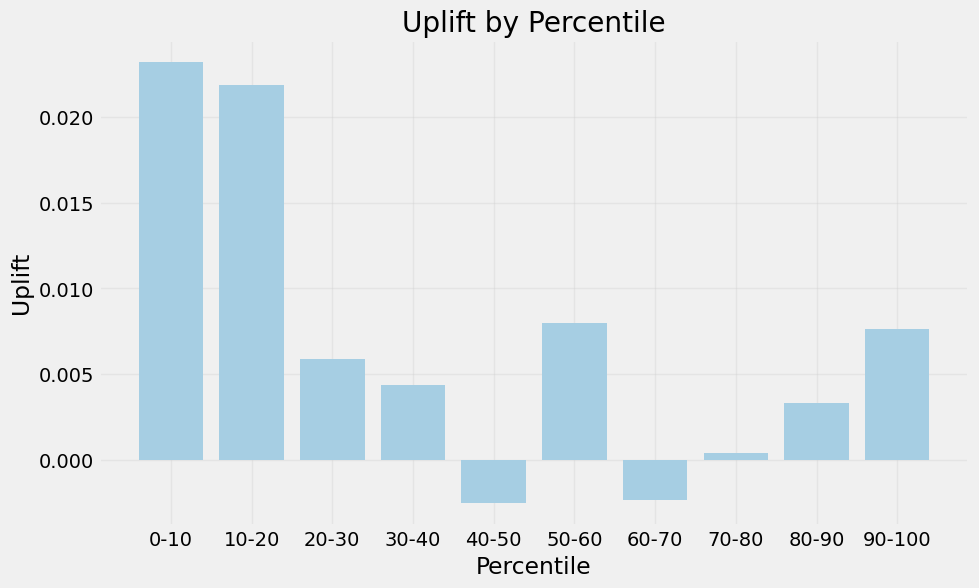

In [22]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v1, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 2 - Пошаговый жадный отбор (Forward Stepwise) по PUC.


 Идея: на каждом шаге добавляем признак, который максимизирует
    совокупный PUC-AUC предиктора (усреднение нормализованных признаков).

In [23]:
def puc_forward_selector(
    X,
    y,
    treatment,
    n_features_to_select=5,
    min_improvement=0.001,
    feature_names=None):
   
    X = np.array(X, dtype=float)
    
    X_norm = X.copy()
    for i in range(X_norm.shape[1]):
        col_range = X_norm[:, i].max() - X_norm[:, i].min()
        if col_range > 0:
            X_norm[:, i] = (X_norm[:, i] - X_norm[:, i].min()) / col_range
    
    y = np.array(y)
    treatment = np.array(treatment)
    n_features = X_norm.shape[1]
    
    remaining = list(range(n_features))
    selected = []
    current_score = 0.0
    selection_history = []
    
    for step in range(n_features_to_select):
        best_score = current_score
        best_feat = None
        
        for feat in remaining:
            score = _compute_marginal_puc(X_norm, y, treatment, selected, feat)
            if score > best_score:
                best_score = score
                best_feat = feat
        
        improvement = best_score - current_score
        if best_feat is None or improvement < min_improvement:
            break
        
        selected.append(best_feat)
        remaining.remove(best_feat)
        current_score = best_score
        
        selection_history.append({
            'step': step + 1,
            'feature': feature_names[best_feat],
            'feature_idx': best_feat,
            'puc_auc': best_score,
            'improvement': improvement
        })
    
    selected_features = np.array(selected)
    summary_df = pd.DataFrame(selection_history)
    
    return selected_features, selection_history, summary_df


In [24]:
selected_idx_fs, feature_scores_fs, summary_df_fs = puc_forward_selector(X_train, y_train, treatment_train, n_features_to_select=10,
                                                                         min_improvement=0.005, feature_names=X_train.columns.tolist())

In [25]:
selected_features_fs = summary_df_fs['feature']

In [26]:
model_t_v2, model_c_v2, uplift_pred_train_v2, auuc_train_v2, puc_train_v2, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_fs)

[I 2026-05-02 18:26:56,109] A new study created in memory with name: no-name-bf109222-1b48-498d-8923-ee42c65e318e
[I 2026-05-02 18:27:46,194] Trial 7 finished with value: 0.017786905312532644 and parameters: {'depth_c': 6, 'learning_rate_c': 0.03220519508483719, 'iterations_c': 846, 'l2_leaf_reg_c': 8.810499690518352, 'bagging_temperature_c': 2.435766305122625, 'random_strength_c': 7.92770859780388, 'min_data_in_leaf_c': 20, 'depth_t': 8, 'learning_rate_t': 0.08033979887900235, 'iterations_t': 392, 'l2_leaf_reg_t': 3.0768045884372817, 'bagging_temperature_t': 7.786560331413931, 'random_strength_t': 2.8055426380030255, 'min_data_in_leaf_t': 39}. Best is trial 7 with value: 0.017786905312532644.


AUUC: 0.39351361008909225
PUC: 0.017786905312532644


[I 2026-05-02 18:27:54,803] Trial 6 finished with value: 0.009972285450916848 and parameters: {'depth_c': 7, 'learning_rate_c': 0.28984867562222105, 'iterations_c': 823, 'l2_leaf_reg_c': 13.257445079596671, 'bagging_temperature_c': 9.404590282794608, 'random_strength_c': 1.2596559091130988, 'min_data_in_leaf_c': 92, 'depth_t': 7, 'learning_rate_t': 0.11972854386483242, 'iterations_t': 528, 'l2_leaf_reg_t': 6.371399067022287, 'bagging_temperature_t': 0.26375396597270395, 'random_strength_t': 0.18258578052457897, 'min_data_in_leaf_t': 26}. Best is trial 7 with value: 0.017786905312532644.


AUUC: 0.41146718487584594
PUC: 0.009972285450916848


[I 2026-05-02 18:27:59,694] Trial 3 finished with value: 0.009119954541713209 and parameters: {'depth_c': 6, 'learning_rate_c': 0.13226629730182524, 'iterations_c': 1230, 'l2_leaf_reg_c': 10.847751633844691, 'bagging_temperature_c': 3.921508098175328, 'random_strength_c': 3.840599824701595, 'min_data_in_leaf_c': 60, 'depth_t': 9, 'learning_rate_t': 0.04826406990110923, 'iterations_t': 422, 'l2_leaf_reg_t': 6.30146539182072, 'bagging_temperature_t': 7.718000353752684, 'random_strength_t': 8.125876532837394, 'min_data_in_leaf_t': 30}. Best is trial 7 with value: 0.017786905312532644.
[I 2026-05-02 18:27:59,722] Trial 13 finished with value: 0.012542448124983428 and parameters: {'depth_c': 6, 'learning_rate_c': 0.16402012159084642, 'iterations_c': 896, 'l2_leaf_reg_c': 19.85988440365113, 'bagging_temperature_c': 1.0331561619706442, 'random_strength_c': 9.877161724408277, 'min_data_in_leaf_c': 53, 'depth_t': 10, 'learning_rate_t': 0.07862597460179638, 'iterations_t': 455, 'l2_leaf_reg_t': 

...

AUUC: 0.5198351936783212
PUC: 0.06986206268330714


[I 2026-05-02 18:31:08,930] Trial 49 finished with value: 0.037620465434155786 and parameters: {'depth_c': 7, 'learning_rate_c': 0.013130223666964501, 'iterations_c': 537, 'l2_leaf_reg_c': 18.474193299854427, 'bagging_temperature_c': 8.65538721252122, 'random_strength_c': 8.411478563278738, 'min_data_in_leaf_c': 68, 'depth_t': 5, 'learning_rate_t': 0.03853882026783976, 'iterations_t': 302, 'l2_leaf_reg_t': 15.077601654656544, 'bagging_temperature_t': 4.03999515590633, 'random_strength_t': 8.44981561679257, 'min_data_in_leaf_t': 81}. Best is trial 39 with value: 0.08063812502632899.


AUUC: 0.36906773479766136
PUC: 0.037620465434155786


[I 2026-05-02 18:31:09,265] Trial 45 finished with value: 0.04570912639933804 and parameters: {'depth_c': 5, 'learning_rate_c': 0.013556414917182565, 'iterations_c': 503, 'l2_leaf_reg_c': 18.03265933360307, 'bagging_temperature_c': 8.03314848311129, 'random_strength_c': 8.445566246824047, 'min_data_in_leaf_c': 72, 'depth_t': 5, 'learning_rate_t': 0.037135233650554905, 'iterations_t': 811, 'l2_leaf_reg_t': 11.84873267425899, 'bagging_temperature_t': 6.381058047659699, 'random_strength_t': 8.354103222585016, 'min_data_in_leaf_t': 84}. Best is trial 39 with value: 0.08063812502632899.


AUUC: 0.44765688220612243
PUC: 0.04570912639933804
AUUC: 0.6803266960311631
PUC: 0.08616653977980016


In [27]:
uplift_pred_test_v2, auuc_test_v2, puc_test_v2 = get_uplift(model_t_v2, model_c_v2, X_test, treatment_test, y_test, selected_features_fs)

AUUC: 0.5646860450243367
PUC: 0.08535796604878862


In [28]:
len(selected_features_fs)

3

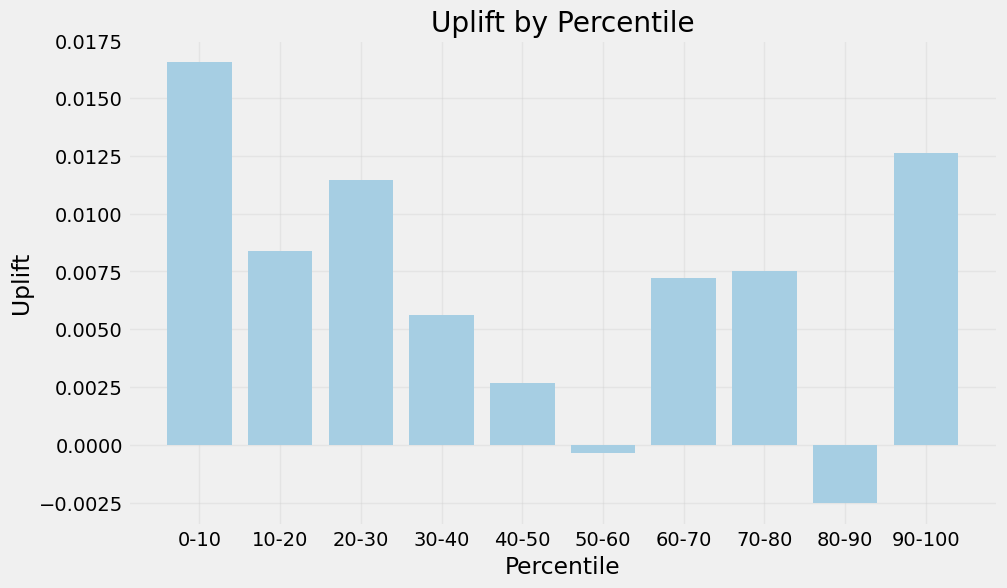

In [29]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v2, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 3 - puc_permutation_importance — Permutation Importance на основе PUC

Метод оценивает важность признака по тому, насколько сильно падает качество uplift-предсказания при случайном перемешивании (permutation) значений этого признака. Чем сильнее падение — тем важнее признак.

In [30]:
def puc_permutation_importance(
    X,
    y,
    treatment,
    uplift_scores,
    n_repeats=20,
    random_state=42,
    feature_names=None
):

    X = np.array(X, dtype=float)
    y = np.array(y)
    treatment = np.array(treatment)
    uplift_scores = np.array(uplift_scores, dtype=float)
    n_features = X.shape[1]
    
    base_score = principled_uplift_auc_score(y, uplift_scores, treatment)
    
    rng = np.random.RandomState(random_state)
    importances = np.zeros((n_features, n_repeats))
    
    for feat_idx in range(n_features):
        for rep in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, feat_idx] = rng.permutation(X[:, feat_idx])
            
            perm_score_col = X_permuted[:, feat_idx]
            col_range = perm_score_col.max() - perm_score_col.min()
            if col_range > 0:
                perm_score_col = (perm_score_col - perm_score_col.min()) / col_range
            
            blended = 0.5 * uplift_scores + 0.5 * perm_score_col
            blended_range = blended.max() - blended.min()
            if blended_range > 0:
                blended = (blended - blended.min()) / blended_range
            
            try:
                perm_puc = principled_uplift_auc_score(y, blended, treatment)
            except Exception:
                perm_puc = base_score
            
            importances[feat_idx, rep] = base_score - perm_puc
    
    importances_mean = importances.mean(axis=1)
    importances_std = importances.std(axis=1)
    
    summary_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': importances_mean,
        'importance_std': importances_std,
    }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    
    return importances, importances_mean, importances_std, base_score, summary_df

In [31]:
model_trt = BASE_MODEL.copy()
model_ctrl = BASE_MODEL.copy()

model_trt.fit(X_train[treatment_train == 1], y_train[treatment_train == 1])
model_ctrl.fit(X_train[treatment_train == 0], y_train[treatment_train == 0])

CatBoostClassifier(loss_function='Logloss', random_state=42, verbose=False)

In [32]:
uplift_scores = model_trt.predict(X_val) - model_ctrl.predict(X_val)

importances, imp_mean, imp_std, base_score, summary_df = puc_permutation_importance(
    X=X_val,
    y=y_val,
    treatment=treatment_val,
    uplift_scores=uplift_scores,
    n_repeats=10,
    random_state=42,
    feature_names=X_train.columns.tolist()
)

In [33]:
selected_features_puc_pi = summary_df[summary_df.importance_mean > 0]['feature']

In [34]:
model_t_v3, model_c_v3, uplift_pred_train_v3, auuc_train_v3, puc_train_v3, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_puc_pi)

[I 2026-05-02 18:33:31,873] A new study created in memory with name: no-name-d93e66ee-69c4-4930-b006-f1cb9e21a2cb
[I 2026-05-02 18:37:23,484] Trial 6 finished with value: 0.03719901019270228 and parameters: {'depth_c': 10, 'learning_rate_c': 0.04196360884253039, 'iterations_c': 330, 'l2_leaf_reg_c': 12.212263411801802, 'bagging_temperature_c': 6.3997347059114995, 'random_strength_c': 1.3176478449013151, 'min_data_in_leaf_c': 59, 'depth_t': 4, 'learning_rate_t': 0.2201813738853399, 'iterations_t': 315, 'l2_leaf_reg_t': 17.573341124252398, 'bagging_temperature_t': 6.664467051571377, 'random_strength_t': 5.523507211303469, 'min_data_in_leaf_t': 12}. Best is trial 6 with value: 0.03719901019270228.


AUUC: 0.5743524180281734
PUC: 0.03719901019270228


[I 2026-05-02 18:37:40,950] Trial 11 finished with value: 0.02469433727403979 and parameters: {'depth_c': 6, 'learning_rate_c': 0.1890781288170648, 'iterations_c': 364, 'l2_leaf_reg_c': 4.249958179838063, 'bagging_temperature_c': 2.360068647504491, 'random_strength_c': 5.596081349744394, 'min_data_in_leaf_c': 10, 'depth_t': 4, 'learning_rate_t': 0.10632754129625968, 'iterations_t': 986, 'l2_leaf_reg_t': 7.725281533097615, 'bagging_temperature_t': 8.537298482727438, 'random_strength_t': 1.1644422641246455, 'min_data_in_leaf_t': 79}. Best is trial 6 with value: 0.03719901019270228.


AUUC: 0.6563482254772097
PUC: 0.02469433727403979


[I 2026-05-02 18:37:49,754] Trial 3 finished with value: 0.01690006774733157 and parameters: {'depth_c': 8, 'learning_rate_c': 0.056309871987454796, 'iterations_c': 604, 'l2_leaf_reg_c': 17.239974980317477, 'bagging_temperature_c': 5.323490808106113, 'random_strength_c': 0.9895976866264566, 'min_data_in_leaf_c': 90, 'depth_t': 4, 'learning_rate_t': 0.0397796837102744, 'iterations_t': 664, 'l2_leaf_reg_t': 2.6315383721634626, 'bagging_temperature_t': 4.091522890946674, 'random_strength_t': 5.414289713605886, 'min_data_in_leaf_t': 6}. Best is trial 6 with value: 0.03719901019270228.


...

AUUC: 0.5816536597999866
PUC: 0.02932455658646593


[I 2026-05-02 19:23:57,917] Trial 46 finished with value: 0.04541598488402914 and parameters: {'depth_c': 8, 'learning_rate_c': 0.22574549709672093, 'iterations_c': 1474, 'l2_leaf_reg_c': 3.3970123135039865, 'bagging_temperature_c': 9.940223429992264, 'random_strength_c': 9.19356421521272, 'min_data_in_leaf_c': 53, 'depth_t': 7, 'learning_rate_t': 0.1527742552509125, 'iterations_t': 1225, 'l2_leaf_reg_t': 12.739663270029217, 'bagging_temperature_t': 2.9875137921716126, 'random_strength_t': 7.979390092505405, 'min_data_in_leaf_t': 87}. Best is trial 7 with value: 0.0642613933512225.


AUUC: 0.7322582226438555
PUC: 0.04541598488402914


[I 2026-05-02 19:24:04,011] Trial 48 finished with value: 0.039478647887206 and parameters: {'depth_c': 8, 'learning_rate_c': 0.18748651681510833, 'iterations_c': 996, 'l2_leaf_reg_c': 3.559953326405902, 'bagging_temperature_c': 1.0301769688195914, 'random_strength_c': 9.002125074935977, 'min_data_in_leaf_c': 50, 'depth_t': 7, 'learning_rate_t': 0.015960207948598315, 'iterations_t': 1334, 'l2_leaf_reg_t': 16.318139873103338, 'bagging_temperature_t': 3.3783696184914342, 'random_strength_t': 8.029015215679259, 'min_data_in_leaf_t': 100}. Best is trial 7 with value: 0.0642613933512225.


AUUC: 0.6140867894312064
PUC: 0.039478647887206
AUUC: 3.240003481136413
PUC: 0.18448091267032785


In [35]:
uplift_pred_test_v3, auuc_test_v3, puc_test_v3 = get_uplift(model_t_v3, model_c_v3, X_test, treatment_test, y_test, selected_features_puc_pi)

AUUC: 0.6662631452491256
PUC: 0.06653041280756339


In [36]:
len(selected_features_puc_pi)

192

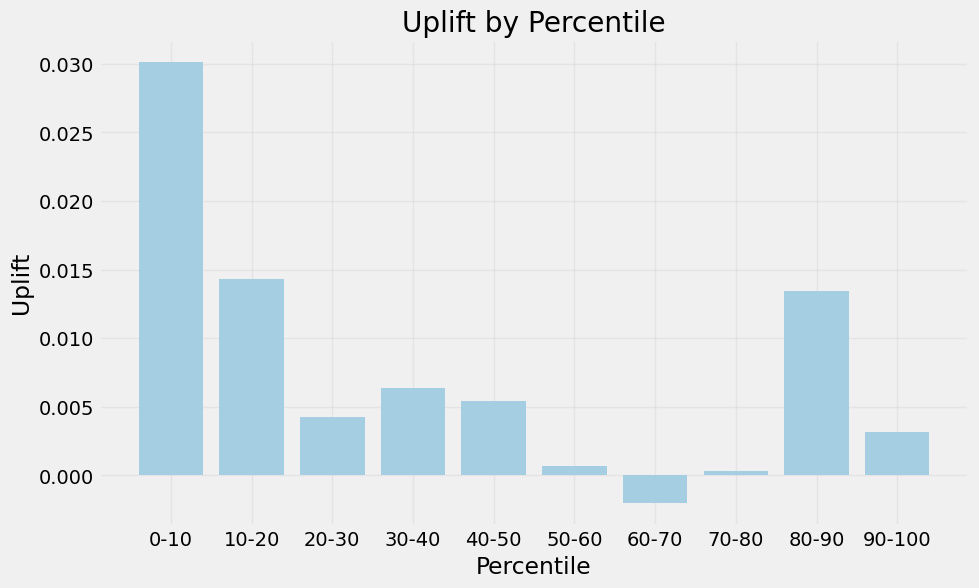

In [37]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v3, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 4 -  Гибридный каузально-PUC отбор признаков.

Идея объединения каузального анализа и PUC:

Uplift-моделирование — это задача оценки индивидуального каузального эффекта (ITE/CATE). В каузальном графе (DAG) признаки делятся на:
    
    1. Confounder (Z): влияет и на T, и на Y → обязательно включать
    2. Effect Modifier (X): меняет CATE, но не T → именно они нужны
    3. Instrument (W): влияет только на T → включать опасно (смещение)
    4. Collider (C): общий потомок T и Y → включать запрещено (смещение)

In [38]:
def causal_puc_selector(
    X,
    y,
    treatment,
    alpha=0.6,
    beta=0.3,
    gamma=0.5,
    top_k=None,
    threshold=0.0,
    feature_names=None
):

    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    treatment = np.array(treatment, dtype=float)
    n_features = X.shape[1]
    
    records = []
    for i in range(n_features):
        xi = X[:, i]
        corr_y, _ = stats.spearmanr(xi, y)
        corr_t, _ = stats.spearmanr(xi, treatment)
        puc_score = _compute_puc_for_feature(xi, y, treatment)
        
        causal_score = (
            alpha * max(puc_score, 0)
            + beta * (abs(corr_y) - gamma * abs(corr_t))
        )
        
        role = _causal_role(corr_y, corr_t, puc_score)
        
        records.append({
            'feature': feature_names[i],
            'feature_idx': i,
            'puc_auc': puc_score,
            'corr_outcome': corr_y,
            'corr_treatment': corr_t,
            'causal_score': causal_score,
            'causal_role': role,
        })
    
    summary_df = pd.DataFrame(records).sort_values(
        'causal_score', ascending=False
    ).reset_index(drop=True)
    
    if top_k is not None:
        selected = summary_df.head(top_k)
    else:
        selected = summary_df[summary_df['causal_score'] >= threshold]
    
    selected_features = selected['feature'].values
    
    return selected_features, summary_df


def _causal_role(corr_y: float, corr_t: float, puc: float) -> str:

    if abs(corr_t) > 0.3 and abs(corr_y) > 0.3:
        return 'confounder'
    elif abs(corr_t) > 0.3 and abs(corr_y) < 0.15:
        return 'instrument'
    elif abs(corr_t) < 0.15 and abs(corr_y) > 0.3:
        return 'prognostic'
    elif puc > 0.05:
        return 'effect_modifier'
    else:
        return 'noise'


In [39]:
selected_features_causal, summary_df_causal = causal_puc_selector(
    X=X_train,
    y=y_train,
    treatment=treatment_train,
    alpha=0.6,
    beta=0.3,
    gamma=0.5,
    top_k=50,
    feature_names=X_train.columns.tolist()
)


In [40]:
model_t_v4, model_c_v4, uplift_pred_train_v4, auuc_train_v4, puc_train_v4, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_causal)

[I 2026-05-02 19:24:59,430] A new study created in memory with name: no-name-acaaf993-5a53-4ab6-887c-c9949885c6ce
[I 2026-05-02 19:26:40,427] Trial 13 finished with value: 0.0011858028298353212 and parameters: {'depth_c': 6, 'learning_rate_c': 0.15291482254538388, 'iterations_c': 877, 'l2_leaf_reg_c': 18.178401087233322, 'bagging_temperature_c': 9.170783367258968, 'random_strength_c': 5.1639982812321525, 'min_data_in_leaf_c': 95, 'depth_t': 7, 'learning_rate_t': 0.04672008284900561, 'iterations_t': 327, 'l2_leaf_reg_t': 19.985841892982197, 'bagging_temperature_t': 4.247526596247394, 'random_strength_t': 5.238429098693826, 'min_data_in_leaf_t': 48}. Best is trial 13 with value: 0.0011858028298353212.


AUUC: 0.5612591267576841
PUC: 0.0011858028298353212


[I 2026-05-02 19:27:31,775] Trial 12 finished with value: 0.009183204194445132 and parameters: {'depth_c': 8, 'learning_rate_c': 0.07193932095434116, 'iterations_c': 548, 'l2_leaf_reg_c': 10.636793670922888, 'bagging_temperature_c': 2.6715849167757, 'random_strength_c': 1.837364142792014, 'min_data_in_leaf_c': 19, 'depth_t': 8, 'learning_rate_t': 0.0267638808968233, 'iterations_t': 617, 'l2_leaf_reg_t': 2.9747936617180284, 'bagging_temperature_t': 2.2370548826376835, 'random_strength_t': 6.406275160194376, 'min_data_in_leaf_t': 5}. Best is trial 12 with value: 0.009183204194445132.


AUUC: 0.47671204568464953
PUC: 0.009183204194445132


[I 2026-05-02 19:28:07,067] Trial 3 finished with value: 0.04147769890006008 and parameters: {'depth_c': 8, 'learning_rate_c': 0.011457005285621035, 'iterations_c': 878, 'l2_leaf_reg_c': 5.235878586035844, 'bagging_temperature_c': 0.9003841714227356, 'random_strength_c': 7.2121395117613645, 'min_data_in_leaf_c': 25, 'depth_t': 4, 'learning_rate_t': 0.027158276346574327, 'iterations_t': 1021, 'l2_leaf_reg_t': 10.149843840800827, 'bagging_temperature_t': 9.451183588932935, 'random_strength_t': 5.492441855813465, 'min_data_in_leaf_t': 44}. Best is trial 3 with value: 0.04147769890006008.


...

AUUC: 0.4887254719909686
PUC: 0.04064234829554261


[I 2026-05-02 19:42:57,335] Trial 41 finished with value: 0.018459408107908633 and parameters: {'depth_c': 10, 'learning_rate_c': 0.07598733676841928, 'iterations_c': 1275, 'l2_leaf_reg_c': 12.253823365816483, 'bagging_temperature_c': 2.076599346903824, 'random_strength_c': 1.3764258911038643, 'min_data_in_leaf_c': 18, 'depth_t': 9, 'learning_rate_t': 0.10670173318268499, 'iterations_t': 1439, 'l2_leaf_reg_t': 13.27714398756798, 'bagging_temperature_t': 6.746252944833648, 'random_strength_t': 8.211899005824543, 'min_data_in_leaf_t': 21}. Best is trial 29 with value: 0.04935827296588839.


AUUC: 0.3734830104989311
PUC: 0.018459408107908633


[I 2026-05-02 19:42:57,589] Trial 48 finished with value: 0.015323184579243572 and parameters: {'depth_c': 10, 'learning_rate_c': 0.06751293469449916, 'iterations_c': 1028, 'l2_leaf_reg_c': 19.936461591128502, 'bagging_temperature_c': 5.445753403822858, 'random_strength_c': 3.670539412135594, 'min_data_in_leaf_c': 13, 'depth_t': 6, 'learning_rate_t': 0.17690040421851566, 'iterations_t': 1480, 'l2_leaf_reg_t': 18.046006675230128, 'bagging_temperature_t': 8.554729343647773, 'random_strength_t': 2.234623696052103, 'min_data_in_leaf_t': 68}. Best is trial 29 with value: 0.04935827296588839.


AUUC: 0.36377730826537724
PUC: 0.015323184579243572
AUUC: 9.354384800810823
PUC: 0.2445049511288082


In [41]:
uplift_pred_test_v4, auuc_test_v4, puc_test_v4 = get_uplift(model_t_v4, model_c_v4, X_test, treatment_test, y_test, selected_features_causal)

AUUC: 0.6737943744330109
PUC: 0.05555321232016247


In [42]:
len(selected_features_causal)

50

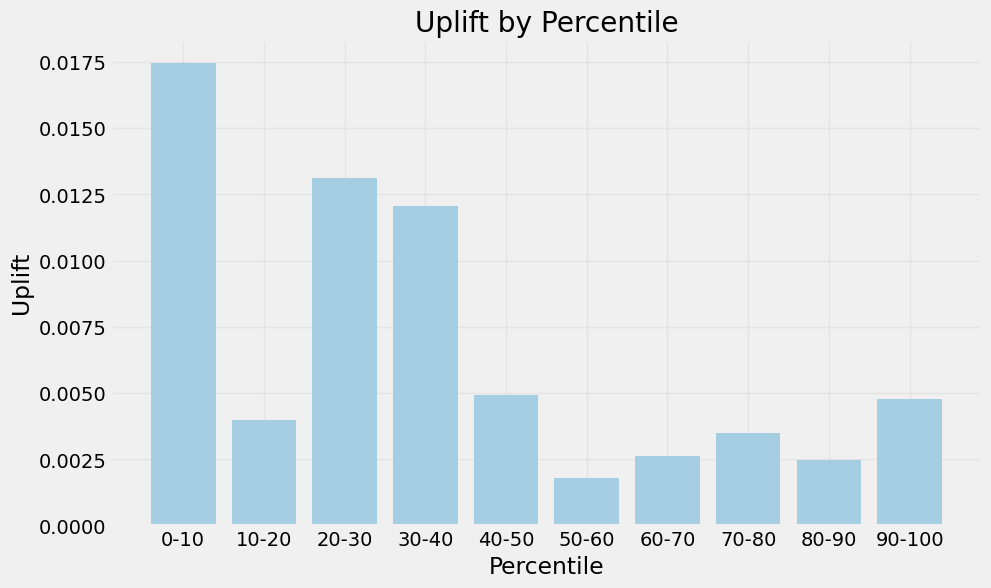

In [43]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v4, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

### Метод 5 - PUCUpliftTree

Дерево принятия решений для uplift-моделирования, использующее PUC-gain как критерий качества разбиения (вместо стандартного KL-дивергенции или ED²/Chi² из пакета CausalML).
    
Критерий разбиения:
```
    PUC_gain(split) = PUC_AUC(left_child) · w_left
                    + PUC_AUC(right_child) · w_right
                    - PUC_AUC(parent)
```
где w_left/w_right — доли наблюдений в дочерних узлах.

Важность признаков вычисляется как суммарный взвешенный PUC-gain по всем разбиениям дерева, использующим данный признак.


In [44]:
class PUCUpliftTreeNode:

    def __init__(self, depth=0):
        self.depth = depth
        self.feature_idx = None
        self.threshold = None
        self.left = None
        self.right = None
        self.is_leaf = False
        self.uplift_score = None
        self.n_samples = None
        self.n_treatment = None
        self.n_control = None
        self.puc_gain = 0.0
        self.y_mean_t = None
        self.y_mean_c = None


class PUCUpliftTree:

    def __init__(self, max_depth=4, min_samples_leaf=50, n_thresholds=10):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.root_ = None
        self.feature_importances_ = None
        self.n_features_ = None
        self.feature_names_ = None
        self._split_records = []

    def _node_puc(self, y, treatment):
        n_t = treatment.sum()
        n_c = len(treatment) - n_t
        if n_t < 5 or n_c < 5:
            return 0.0
        if len(np.unique(y)) < 2:
            return 0.0

        try:
            proxy_uplift = y * treatment - y * (1 - treatment)
            return principled_uplift_auc_score(y, proxy_uplift.astype(float), treatment)
        except Exception:
            return 0.0

    def _best_split(self, X, y, treatment):
        n = len(y)
        best_gain = -np.inf
        best_feat = None
        best_thresh = None

        parent_puc = self._node_puc(y, treatment)

        for feat_idx in range(X.shape[1]):
            values = X[:, feat_idx]
            thresholds = np.percentile(
                values,
                np.linspace(10, 90, self.n_thresholds)
            )
            thresholds = np.unique(thresholds)

            for thresh in thresholds:
                left_mask = values <= thresh
                right_mask = ~left_mask

                n_left = left_mask.sum()
                n_right = right_mask.sum()

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                puc_left = self._node_puc(y[left_mask], treatment[left_mask])
                puc_right = self._node_puc(y[right_mask], treatment[right_mask])

                gain = (
                    puc_left * (n_left / n)
                    + puc_right * (n_right / n)
                    - parent_puc
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat_idx
                    best_thresh = thresh

        return best_feat, best_thresh, best_gain

    def _build(self, X, y, treatment, depth):
        node = PUCUpliftTreeNode(depth=depth)
        node.n_samples = len(y)
        node.n_treatment = treatment.sum()
        node.n_control = node.n_samples - node.n_treatment

        y_t = y[treatment == 1]
        y_c = y[treatment == 0]
        node.y_mean_t = y_t.mean() if len(y_t) > 0 else 0.0
        node.y_mean_c = y_c.mean() if len(y_c) > 0 else 0.0
        node.uplift_score = node.y_mean_t - node.y_mean_c

        if (depth >= self.max_depth
                or node.n_treatment < self.min_samples_leaf
                or node.n_control < self.min_samples_leaf):
            node.is_leaf = True
            return node

        feat, thresh, gain = self._best_split(X, y, treatment)

        if feat is None or gain <= 0:
            node.is_leaf = True
            return node

        node.feature_idx = feat
        node.threshold = thresh
        node.puc_gain = gain

        self._split_records.append({
            'feature_idx': feat,
            'gain': gain,
            'n_samples': node.n_samples
        })

        mask_left = X[:, feat] <= thresh
        mask_right = ~mask_left

        node.left = self._build(X[mask_left], y[mask_left], treatment[mask_left], depth + 1)
        node.right = self._build(X[mask_right], y[mask_right], treatment[mask_right], depth + 1)

        return node

    def fit(self, X, y, treatment, feature_names=None):
        X = np.array(X, dtype=float)
        y = np.array(y)
        treatment = np.array(treatment)
        self.n_features_ = X.shape[1]

        self.feature_names_ = feature_names

        self._split_records = []
        self.root_ = self._build(X, y, treatment, depth=0)

        importances = np.zeros(self.n_features_)
        for record in self._split_records:
            importances[record['feature_idx']] += (
                record['gain'] * record['n_samples']
            )

        total = importances.sum()
        if total > 0:
            importances /= total
        self.feature_importances_ = importances
        return self

    def _predict_node(self, x, node):
        if node.is_leaf:
            return node.uplift_score
        if x[node.feature_idx] <= node.threshold:
            return self._predict_node(x, node.left)
        else:
            return self._predict_node(x, node.right)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.array([self._predict_node(x, self.root_) for x in X])

    def get_feature_importance_df(self):
        return pd.DataFrame({
            'feature': self.feature_names_,
            'importance': self.feature_importances_,
        }).sort_values('importance', ascending=False)

    def _print_tree(self, node, prefix='', is_left=True):
        if node is None:
            return
        connector = '├── ' if is_left else '└── '
        if node.is_leaf:
            print(f'{prefix}{connector}[LEAF] uplift={node.uplift_score:.4f}'
                  f'n={node.n_samples} (T={node.n_treatment}, C={node.n_control})')
        else:
            feat_name = self.feature_names_[node.feature_idx]
            print(f'{prefix}{connector}[{feat_name} <= {node.threshold:.4f}] '
                  f'puc_gain={node.puc_gain:.4f} n={node.n_samples}')
            ext = '│   ' if is_left else '    '
            self._print_tree(node.left, prefix + ext, True)
            self._print_tree(node.right, prefix + ext, False)

    def print_tree(self):
        print('PUC Uplift Tree')
        self._print_tree(self.root_, '', True)


In [45]:
puc_tree = PUCUpliftTree(max_depth=4, min_samples_leaf=40, n_thresholds=8)
puc_tree.fit(X_train, y_train, treatment_train, feature_names=X_train.columns.tolist())
puc_tree.print_tree()

PUC Uplift Tree
├── [response_sms <= 0.0000] puc_gain=0.0040 n=412191
│   ├── [response_viber <= 0.2000] puc_gain=0.0216 n=71741
│   │   ├── [children <= -100.0000] puc_gain=0.0286 n=23771
│   │   │   ├── [cheque_count_12m_g48 <= 0.0000] puc_gain=0.0005 n=5152
│   │   │   │   ├── [LEAF] uplift=0.0388n=1076 (T=803, C=273)
│   │   │   │   └── [LEAF] uplift=-0.0082n=4076 (T=3106, C=970)
│   │   │   └── [k_var_disc_share_6m_g49 <= 0.0000] puc_gain=0.0295 n=18619
│   │   │       ├── [LEAF] uplift=0.0060n=10877 (T=5997, C=4880)
│   │   │       └── [LEAF] uplift=0.0188n=7742 (T=2084, C=5658)
│   │   └── [response_viber <= 0.9286] puc_gain=0.0023 n=47970
│   │       ├── [response_viber <= 0.5000] puc_gain=0.0315 n=4904
│   │       │   ├── [LEAF] uplift=0.0077n=1626 (T=762, C=864)
│   │       │   └── [LEAF] uplift=0.0078n=3278 (T=2493, C=785)
│   │       └── [k_var_disc_per_cheque_15d <= -100.0000] puc_gain=0.0001 n=43066
│   │           ├── [LEAF] uplift=0.0121n=7954 (T=6043, C=1911)
│   │    

In [46]:
summary_df = puc_tree.get_feature_importance_df()

In [47]:
selected_features_tree = summary_df[summary_df['importance'] > 0]

In [48]:
model_t_v5, model_c_v5, uplift_pred_train_v5, auuc_train_v5, puc_train_v5, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_tree)

[I 2026-05-02 19:47:58,371] A new study created in memory with name: no-name-de750d06-4197-42e0-8aa1-5e491d820096
[I 2026-05-02 19:48:55,118] Trial 7 finished with value: 0.004614431832879007 and parameters: {'depth_c': 7, 'learning_rate_c': 0.06448750826365376, 'iterations_c': 1143, 'l2_leaf_reg_c': 1.1991078121719978, 'bagging_temperature_c': 3.993381466976178, 'random_strength_c': 3.4371712933780216, 'min_data_in_leaf_c': 21, 'depth_t': 6, 'learning_rate_t': 0.21114631555650568, 'iterations_t': 392, 'l2_leaf_reg_t': 12.369643084530129, 'bagging_temperature_t': 6.754521282519685, 'random_strength_t': 8.255336355864957, 'min_data_in_leaf_t': 6}. Best is trial 7 with value: 0.004614431832879007.


AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-05-02 19:48:56,260] Trial 4 finished with value: 0.004614431832879007 and parameters: {'depth_c': 10, 'learning_rate_c': 0.06774668725505284, 'iterations_c': 952, 'l2_leaf_reg_c': 17.40224397137579, 'bagging_temperature_c': 2.4298959553565567, 'random_strength_c': 6.040790527552523, 'min_data_in_leaf_c': 57, 'depth_t': 8, 'learning_rate_t': 0.09418961896708646, 'iterations_t': 469, 'l2_leaf_reg_t': 3.6017460828707666, 'bagging_temperature_t': 3.3344402592250812, 'random_strength_t': 2.685282693061689, 'min_data_in_leaf_t': 76}. Best is trial 7 with value: 0.004614431832879007.


AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-05-02 19:48:56,763] Trial 12 finished with value: 0.004614431832879007 and parameters: {'depth_c': 5, 'learning_rate_c': 0.20540586877194508, 'iterations_c': 949, 'l2_leaf_reg_c': 15.445876992675935, 'bagging_temperature_c': 3.099824451932766, 'random_strength_c': 2.7084200145380635, 'min_data_in_leaf_c': 40, 'depth_t': 9, 'learning_rate_t': 0.0799357427727989, 'iterations_t': 492, 'l2_leaf_reg_t': 6.897757033294438, 'bagging_temperature_t': 8.880968782644414, 'random_strength_t': 9.188849597063339, 'min_data_in_leaf_t': 58}. Best is trial 7 with value: 0.004614431832879007.


...

AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-05-02 19:51:54,753] Trial 45 finished with value: 0.004614431832879007 and parameters: {'depth_c': 10, 'learning_rate_c': 0.010457444656164173, 'iterations_c': 1451, 'l2_leaf_reg_c': 2.009210879236501, 'bagging_temperature_c': 1.4259679521767405, 'random_strength_c': 6.1019742351869475, 'min_data_in_leaf_c': 11, 'depth_t': 4, 'learning_rate_t': 0.04472305017804808, 'iterations_t': 537, 'l2_leaf_reg_t': 14.58834394397309, 'bagging_temperature_t': 0.12529130694181678, 'random_strength_t': 2.7761569119502303, 'min_data_in_leaf_t': 23}. Best is trial 7 with value: 0.004614431832879007.
[I 2026-05-02 19:51:54,846] Trial 48 finished with value: 0.004614431832879007 and parameters: {'depth_c': 10, 'learning_rate_c': 0.010355323812897471, 'iterations_c': 1129, 'l2_leaf_reg_c': 3.7506650552206517, 'bagging_temperature_c': 1.1101614001481186, 'random_strength_c': 9.989773340043847, 'min_data_in_leaf_c': 17, 'depth_t': 6, 'learning_rate_t': 0.1179795570288962, 'iterations_t': 566, 'l2_lea

AUUC: 0.5376657871052333
PUC: 0.004614431832879007
AUUC: 0.5376657871052333
PUC: 0.004614431832879007
AUUC: 0.5376657871052333
PUC: 0.004614431832879007


[I 2026-05-02 19:51:54,957] Trial 46 finished with value: 0.004614431832879007 and parameters: {'depth_c': 10, 'learning_rate_c': 0.011146152617467233, 'iterations_c': 1468, 'l2_leaf_reg_c': 19.797268994034496, 'bagging_temperature_c': 1.6340788690038428, 'random_strength_c': 9.64617630636286, 'min_data_in_leaf_c': 1, 'depth_t': 4, 'learning_rate_t': 0.11489876129172365, 'iterations_t': 570, 'l2_leaf_reg_t': 19.138496283625706, 'bagging_temperature_t': 0.39781806953301224, 'random_strength_t': 2.765285408625446, 'min_data_in_leaf_t': 20}. Best is trial 7 with value: 0.004614431832879007.
[I 2026-05-02 19:51:55,133] Trial 49 finished with value: 0.004614431832879007 and parameters: {'depth_c': 10, 'learning_rate_c': 0.010833576247674533, 'iterations_c': 1142, 'l2_leaf_reg_c': 2.323631007262389, 'bagging_temperature_c': 4.3012841515874, 'random_strength_c': 9.284423718673734, 'min_data_in_leaf_c': 16, 'depth_t': 6, 'learning_rate_t': 0.11798631606051435, 'iterations_t': 522, 'l2_leaf_reg

AUUC: 0.5376657871052333
PUC: 0.004614431832879007
AUUC: 0.5766993063708056
PUC: 0.0049645186416363875


In [49]:
len(selected_features_tree)

7

In [50]:
uplift_pred_test_v5, auuc_test_v5, puc_test_v5 = get_uplift(model_t_v5, model_c_v5, X_test, treatment_test, y_test, selected_features_tree)

AUUC: 0.3762017851309128
PUC: 0.001917091159780756


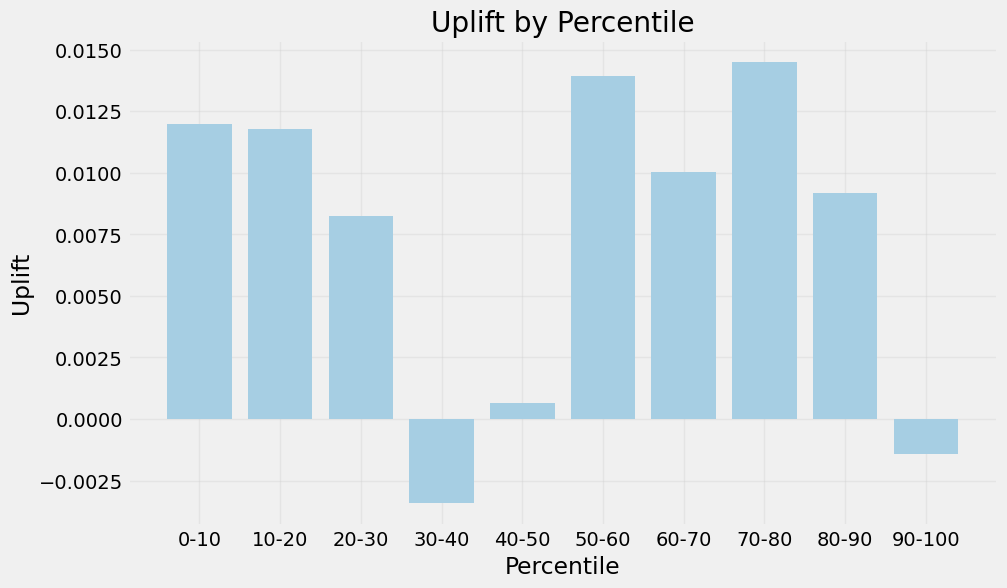

In [51]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v5, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
selected_features_tree_v2 = summary_df['feature'][:50].values

In [53]:
model_t_v6, model_c_v6, uplift_pred_train_v6, auuc_train_v6, puc_train_v6, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_tree_v2)

[I 2026-05-02 19:52:05,059] A new study created in memory with name: no-name-ea578046-86d7-417c-b6f7-4a8403649c07
[I 2026-05-02 19:53:25,410] Trial 1 finished with value: 0.014580991024986677 and parameters: {'depth_c': 4, 'learning_rate_c': 0.10451719556822864, 'iterations_c': 697, 'l2_leaf_reg_c': 2.0632738757503097, 'bagging_temperature_c': 7.042212330229707, 'random_strength_c': 5.139350530063585, 'min_data_in_leaf_c': 68, 'depth_t': 5, 'learning_rate_t': 0.29818830477596714, 'iterations_t': 573, 'l2_leaf_reg_t': 4.16675296408989, 'bagging_temperature_t': 8.4878102936453, 'random_strength_t': 0.2464801171852249, 'min_data_in_leaf_t': 27}. Best is trial 1 with value: 0.014580991024986677.


AUUC: 0.5324542149961189
PUC: 0.014580991024986677


[I 2026-05-02 19:53:34,834] Trial 9 finished with value: 0.0196083994164486 and parameters: {'depth_c': 5, 'learning_rate_c': 0.039536526260247076, 'iterations_c': 563, 'l2_leaf_reg_c': 1.6657313932141729, 'bagging_temperature_c': 4.001951589667534, 'random_strength_c': 2.105612009204223, 'min_data_in_leaf_c': 23, 'depth_t': 4, 'learning_rate_t': 0.022182976142780215, 'iterations_t': 745, 'l2_leaf_reg_t': 5.567077608032505, 'bagging_temperature_t': 2.1653946115142766, 'random_strength_t': 0.38906003320330673, 'min_data_in_leaf_t': 98}. Best is trial 9 with value: 0.0196083994164486.


AUUC: 0.5882804802335144
PUC: 0.0196083994164486


[I 2026-05-02 19:53:48,419] Trial 10 finished with value: 0.0328809071418028 and parameters: {'depth_c': 4, 'learning_rate_c': 0.030175764555146117, 'iterations_c': 575, 'l2_leaf_reg_c': 9.12029628311136, 'bagging_temperature_c': 8.177601277225937, 'random_strength_c': 9.57560887774936, 'min_data_in_leaf_c': 41, 'depth_t': 9, 'learning_rate_t': 0.023546646705617208, 'iterations_t': 482, 'l2_leaf_reg_t': 19.448315600309414, 'bagging_temperature_t': 1.2632169880735478, 'random_strength_t': 1.4999006505987966, 'min_data_in_leaf_t': 91}. Best is trial 10 with value: 0.0328809071418028.


...

AUUC: 0.5815188823013858
PUC: 0.034783963407300285


[I 2026-05-02 20:10:54,988] Trial 49 finished with value: 0.038390510358329195 and parameters: {'depth_c': 9, 'learning_rate_c': 0.17727815403800545, 'iterations_c': 697, 'l2_leaf_reg_c': 10.764080344785105, 'bagging_temperature_c': 4.824195218152688, 'random_strength_c': 5.944597854025877, 'min_data_in_leaf_c': 71, 'depth_t': 5, 'learning_rate_t': 0.0431496314162581, 'iterations_t': 1071, 'l2_leaf_reg_t': 3.0219709214010377, 'bagging_temperature_t': 2.974562788486436, 'random_strength_t': 4.766108224421104, 'min_data_in_leaf_t': 40}. Best is trial 2 with value: 0.060421168614349235.


AUUC: 0.672375838935322
PUC: 0.038390510358329195


[I 2026-05-02 20:10:57,520] Trial 46 finished with value: 0.04869159092780145 and parameters: {'depth_c': 9, 'learning_rate_c': 0.164018999764578, 'iterations_c': 946, 'l2_leaf_reg_c': 3.6061688865380432, 'bagging_temperature_c': 0.16314939383596982, 'random_strength_c': 3.1857369261512405, 'min_data_in_leaf_c': 54, 'depth_t': 5, 'learning_rate_t': 0.014868659462088589, 'iterations_t': 1128, 'l2_leaf_reg_t': 13.656842715180032, 'bagging_temperature_t': 2.9551490929025865, 'random_strength_t': 2.714679872027201, 'min_data_in_leaf_t': 41}. Best is trial 2 with value: 0.060421168614349235.


AUUC: 0.5806741516491112
PUC: 0.04869159092780145
AUUC: 9.061413725199415
PUC: 0.20693906772504356


In [54]:
uplift_pred_test_v6, auuc_test_v6, puc_test_v6 = get_uplift(model_t_v6, model_c_v6, X_test, treatment_test, y_test, selected_features_tree_v2)

AUUC: 0.6373826395178659
PUC: 0.06647993166974994


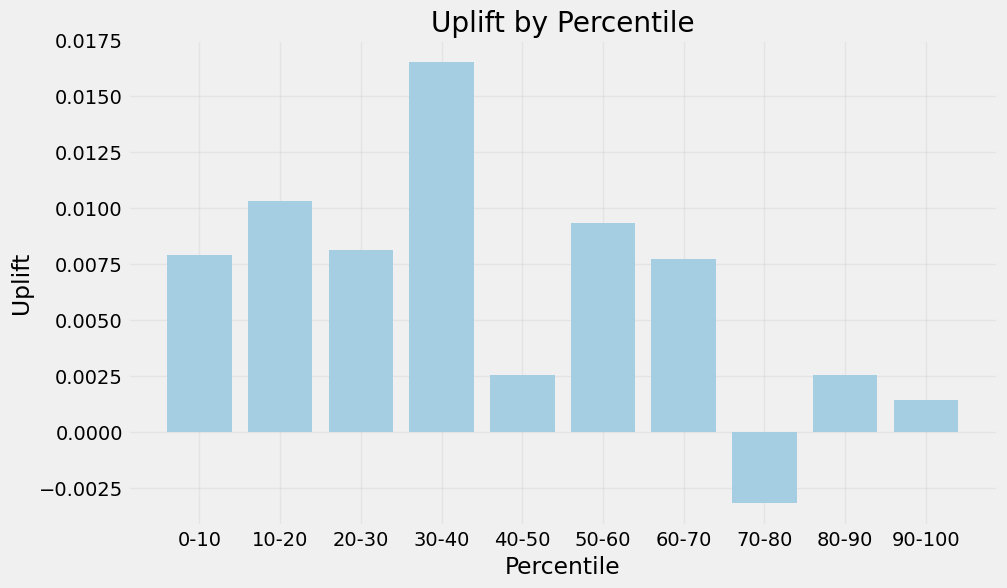

In [55]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v6, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()